# lab 7 clustering 2
Yasir Ahmad 
22MIA1064

In [1]:
!pip install minisom scikit-learn

  Preparing metadata (setup.py) ... - done
  Created wheel for minisom: filename=MiniSom-2.3.3-py3-none-any.whl size=11705 sha256=922fd02b9d349786f83e7ca5d3e6adea37c1c95a6957b8396fc8ae10dbe671e1
  Stored in directory: /root/.cache/pip/wheels/96/98/a5/52dee3e8ed1dbfc4d77e4da41b6d89dd7ab9ead1b921e766f8
Successfully built minisom


In [2]:
import numpy as np
import pandas as pd

# KSOM

In [3]:
# Load the dataset
data = pd.read_csv('/kaggle/input/mall-customers/Mall_Customers.csv')  # Make sure to adjust the path accordingly
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.shape

(200, 5)

In [5]:
# Select relevant features for segmentation (e.g., Annual Income and Spending Score)
features = data[['Annual Income (k$)', 'Spending Score (1-100)']]
# Normalize the features
data_normalized = (features - features.mean()) / features.std()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom

# Specify SOM parameters
n_neurons = 5  # 5x5 grid
m_neurons = 5
sigma = 1.0  # Neighborhood function width
learning_rate = 0.5  # Learning rate
iterations = 1000  # Number of iterations for training
print_interval = 100  # Interval for printing weights

# Initialize SOM
som = MiniSom(n_neurons, m_neurons, data_normalized.shape[1],
               sigma=sigma, learning_rate=learning_rate, random_seed=0)

# Train the SOM and print weights at specified intervals
for i in range(iterations):
    som.train(data_normalized.values, 1)  # Train for 1 iteration
    if i % print_interval == 0:
        print(f"Weights at iteration {i}:\n{som.get_weights()}\n")

Weights at iteration 0:
[[[ 0.22089152  0.9749877 ]
  [ 0.91613566  0.4001666 ]
  [-0.46367589  0.88599003]
  [-0.15732761  0.98754429]
  [ 0.96982517 -0.24380084]]

 [[ 0.97996796  0.09560961]
  [ 0.15149949  0.98267116]
  [-0.72125517 -0.69326715]
  [-0.8218769   0.56968447]
  [ 0.60089068  0.79932564]]

 [[ 0.67322043  0.46481307]
  [-0.20164857  0.93224204]
  [-0.94619929  0.33703344]
  [-0.62650332  0.77917567]
  [ 0.24797635 -0.96874242]]

 [[-0.97991681  0.39710151]
  [-0.75934056  0.60733029]
  [-1.00272175  0.20991833]
  [ 0.68383933  0.71799024]
  [ 0.92506648  0.37906276]]

 [[-1.32359133 -0.4213543 ]
  [-0.24046408 -0.76704197]
  [ 0.53427233  0.6374302 ]
  [-0.62148703 -0.78634723]
  [-0.80460977 -0.5939884 ]]]

Weights at iteration 100:
[[[ 0.18836188  0.95155449]
  [ 0.8893035   0.39172577]
  [-0.46655775  0.88299767]
  [-0.15762149  0.98727948]
  [ 0.96980995 -0.24380191]]

 [[-0.17937236 -0.1304502 ]
  [-0.38873764  0.57698492]
  [-0.7946675  -0.67446447]
  [-0.8274919

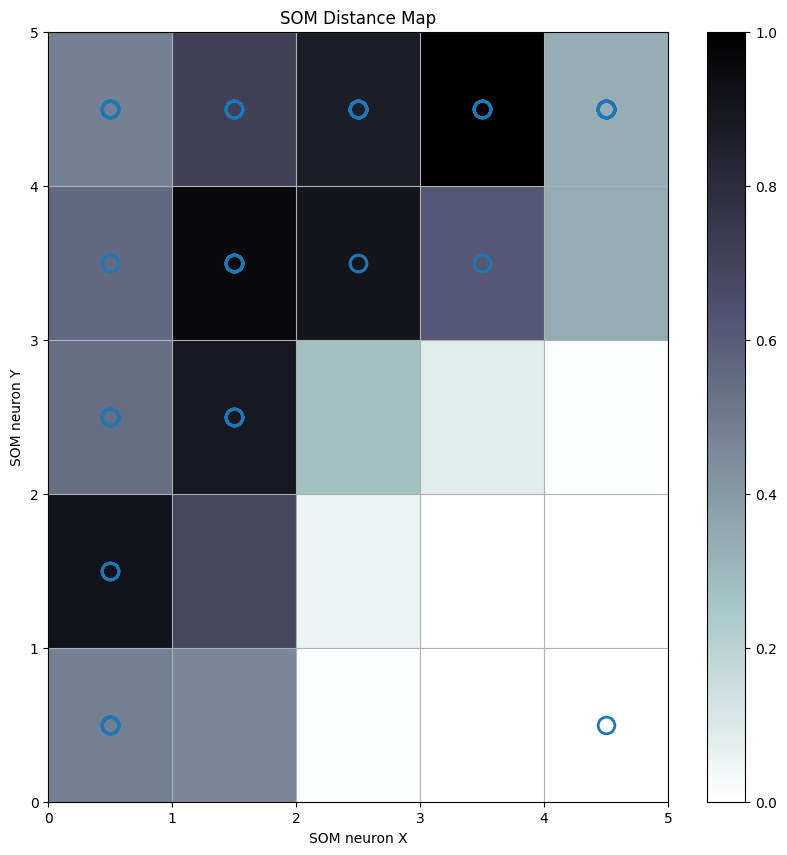

defaultdict(<class 'list'>, {(4, 0): [array([-1.73464625, -0.43371311])], (1, 3): [array([-1.73464625,  1.19271106]), array([-1.69657236,  1.03781352]), array([-1.65849848,  0.99908914]), array([-1.62042459,  1.69612807]), array([-1.5823507,  0.8441916]), array([-1.54427682,  1.03781352]), array([-1.54427682,  1.11526229]), array([-1.39198127,  0.88291598]), array([-1.35390739,  0.88291598]), array([-1.23968573,  1.23143545]), array([-1.16353796,  0.88291598]), array([-1.01124241,  0.88291598]), array([-0.82087298,  0.41822336]), array([-0.82087298,  0.5731209 ]), array([-0.7827991 ,  0.18587705]), array([-0.70665132,  0.06970389]), array([-0.70665132,  0.37949897]), array([-0.66857744,  0.14715266]), array([-0.66857744,  0.37949897]), array([-0.63050355, -0.00774488]), array([-0.55435578,  0.03097951]), array([-0.55435578,  0.22460143]), array([-0.55435578,  0.18587705]), array([-0.51628189,  0.06970389]), array([-0.51628189,  0.34077459]), array([-0.47820801,  0.03097951]), array([-0

In [7]:
# Create a distance map for visualization
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='bone_r')  # Display distance map
plt.colorbar()
plt.title('SOM Distance Map')

# Overlay data points on the distance map
for cnt, xx in enumerate(data_normalized.values):
    w = som.winner(xx)  # Find the Best Matching Unit (BMU)
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o',
             markerfacecolor='None',
             markeredgecolor='C0',
             markersize=12,
             markeredgewidth=2)

plt.xlabel('SOM neuron X')
plt.ylabel('SOM neuron Y')
plt.grid()
plt.show()

# Assign clusters based on the winning neurons
win_map = som.win_map(data_normalized.values)
print(win_map)

# Optionally, assign customers to their SOM clusters
clusters = np.zeros(data.shape[0])
for i, data_point in enumerate(data_normalized.values):
    w = som.winner(data_point)
    clusters[i] = w[0] + (w[1] * n_neurons)

# Add the cluster labels to the original DataFrame for further analysis
data['Cluster'] = clusters
print(data)


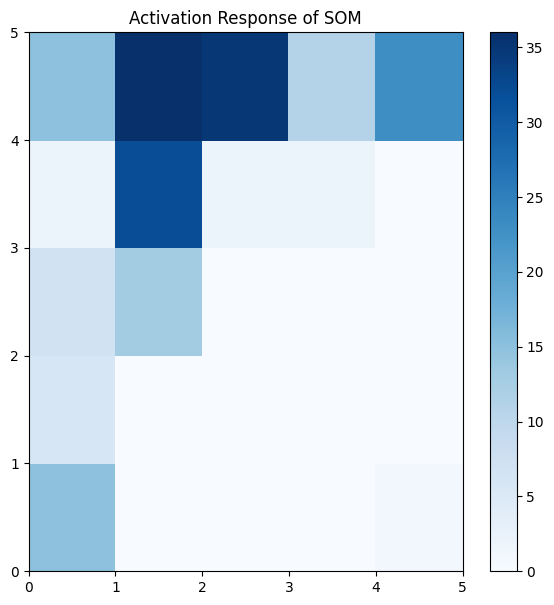

In [8]:
# Frequency plot for each neuron
plt.figure(figsize=(7, 7))
frequencies = som.activation_response(data_normalized.values)
plt.pcolor(frequencies.T, cmap='Blues')
plt.colorbar()
plt.title('Activation Response of SOM')
plt.show()

# CCA-SOM

In [9]:
data = pd.read_csv('/kaggle/input/mall-customers/Mall_Customers.csv')
data.rename(columns={'Genre':'Gender'},inplace=True)
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Self-Organizing Map Weights:
Weight at (0, 0): [-0.754609  -1.7823804]
Weight at (0, 1): [-0.72325609 -1.64227696]
Weight at (0, 2): [-0.98635464 -0.63194208]
Weight at (0, 3): [-0.36663581 -0.27432451]
Weight at (0, 4): [-0.34964416  1.04140313]
Weight at (0, 5): [-0.57855642  1.11242795]
Weight at (0, 6): [-0.66526179  1.0911116 ]
Weight at (0, 7): [-0.8747114   1.02880599]
Weight at (0, 8): [-1.36982281  0.91610397]
Weight at (0, 9): [-1.23615995  0.95075151]

Weight at (1, 0): [-1.18224434 -1.88751928]
Weight at (1, 1): [-1.02435918 -1.8482644 ]
Weight at (1, 2): [-0.84975401 -1.28584039]
Weight at (1, 3): [-0.39573287  0.99964782]
Weight at (1, 4): [-0.3845864  1.1601119]
Weight at (1, 5): [-0.5894644   1.10974702]
Weight at (1, 6): [-0.73022339  1.07514025]
Weight at (1, 7): [-1.07232525  0.9908516 ]
Weight at (1, 8): [-1.49953952  0.88599744]
Weight at (1, 9): [-1.31760151  0.93072842]

Weight at (2, 0): [-1.29716654 -1.91577426]
Weight at (2, 1): [-1.04377017 -1.85300218]
Weigh

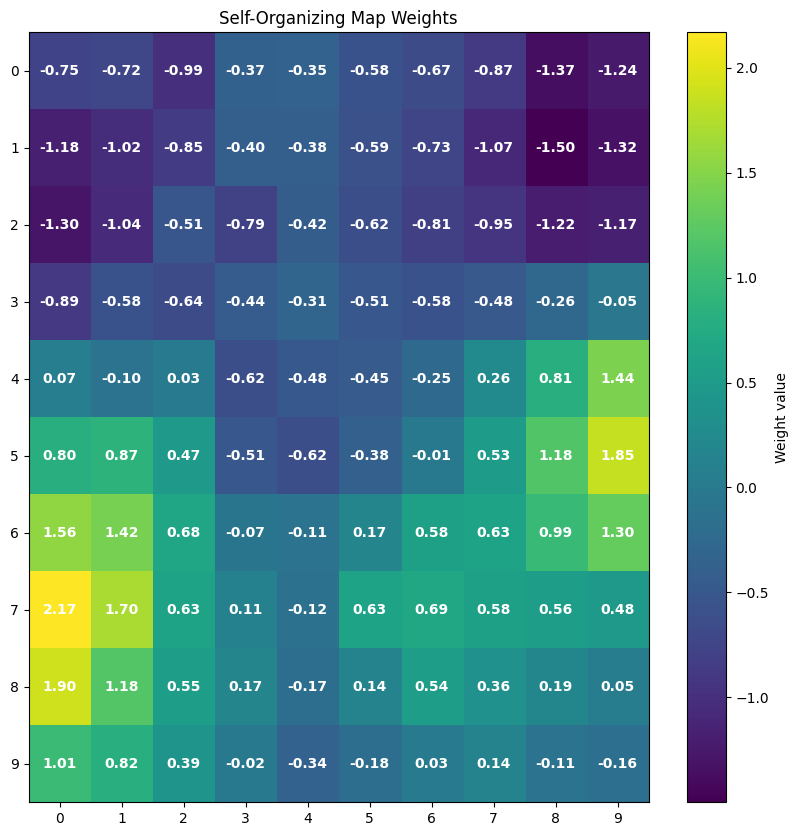

In [10]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from minisom import MiniSom
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame loaded from a CSV or another source
# Example: data = pd.read_csv('your_data.csv')

# Separate features for CCA
demographic_features = data[['Age', 'Gender']]
behavioral_features = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Preprocessing for demographic features including categorical variables
numerical_features = ['Age']
categorical_features = ['Gender']

# Create a Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

# Fit and transform demographic features
X_demographic = preprocessor.fit_transform(demographic_features)

# Standardizing the behavioral features (assuming they are all numerical)
scaler = StandardScaler()
X_behavioral = scaler.fit_transform(behavioral_features)

# Step 3: Perform Canonical Correlation Analysis (CCA)
cca = CCA(n_components=min(X_demographic.shape[1], X_behavioral.shape[1]))
X_c = cca.fit_transform(X_demographic, X_behavioral)

# Ensure X_c is properly transformed
if isinstance(X_c, tuple):
    # If X_c is a tuple, unpack it
    X_c = X_c[0]  # Take the first element if appropriate

# Ensure X_c is a NumPy array
X_som = np.array(X_c)


# Step 5: Implement Self-Organizing Map
som_shape = (10, 10)  # Adjust shape as needed
som = MiniSom(som_shape[0], som_shape[1], X_som.shape[1], sigma=1.0, learning_rate=0.5)

# Random weight initialization
som.random_weights_init(X_som)

# Train the model
som.train(X_som, 1000)  # Train for 1000 iterations

weights = som.get_weights()
# Step 6: Print the weights
print("Self-Organizing Map Weights:")
for x in range(som_shape[0]):
    for y in range(som_shape[1]):
        print(f"Weight at ({x}, {y}): {weights[x][y]}")  # Printing the weights
    print()  # Blank line for better readability between rows of weights

# Visualization Section
fig, ax = plt.subplots(figsize=(10, 10))
weights_array = np.array([[weights[x][y] for y in range(som_shape[1])] for x in range(som_shape[0])])

# Create a heatmap of the first component of the SOM weights for visualization
heatmap = np.array([[weights_array[x][y][0] for y in range(som_shape[1])] for x in range(som_shape[0])])

# Use imshow to visualize the weights
cax = ax.imshow(heatmap, cmap='viridis', aspect='auto')  # You can choose a different colormap

# Add annotations to the cells
for x in range(som_shape[0]):
    for y in range(som_shape[1]):
        ax.text(y, x, f'{weights_array[x][y][0]:.2f}', ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')

plt.title('Self-Organizing Map Weights')
plt.xticks(ticks=range(som_shape[1]), labels=range(som_shape[1]))
plt.yticks(ticks=range(som_shape[0]), labels=range(som_shape[0]))

# Add the color bar here, referencing the heatmap
plt.colorbar(cax, label='Weight value')
plt.grid(False)
plt.show()

# DBSCAN

In [11]:
df = data
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


DBSCAN labels for euclidean distance:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


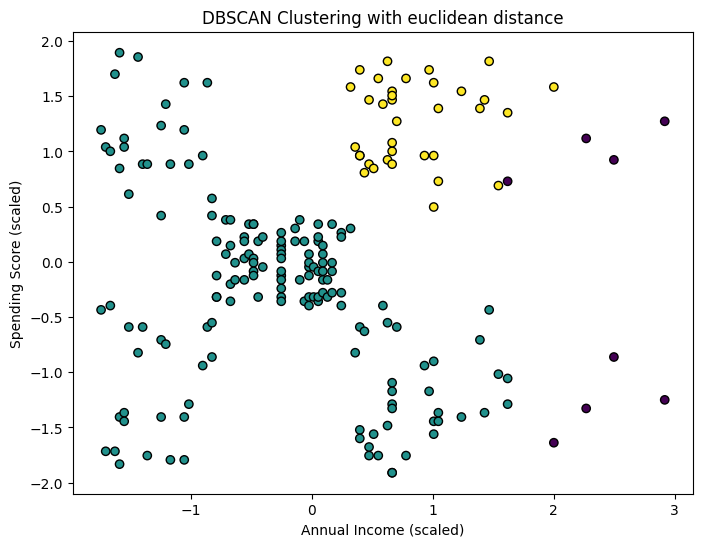

DBSCAN labels for manhattan distance:
[ 0  0  1  0  0  0  1 -1  1  0  1 -1  1  0  1  0  0  0  0 -1  0  0  1  0
  1  0  0  0  0  0  1  0  1  0  1  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  2  0  2  0  2  3  2  3  2  0  2  3  2  3  2  3  2  3  2  0  2
  3  2  0  2  3  2  3  2  3  2  3  2  3  2  3  2  0  2  3  2  3  2  3  2
  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3  2 -1  2  3 -1  3  2  3 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


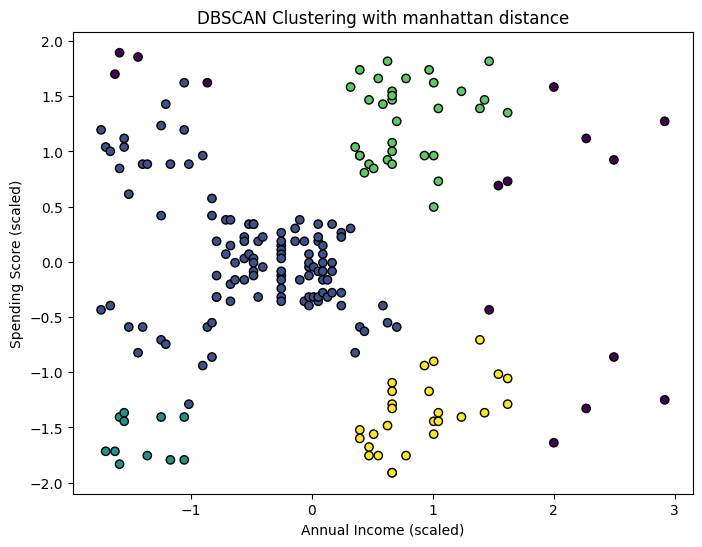

DBSCAN labels for cosine distance:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


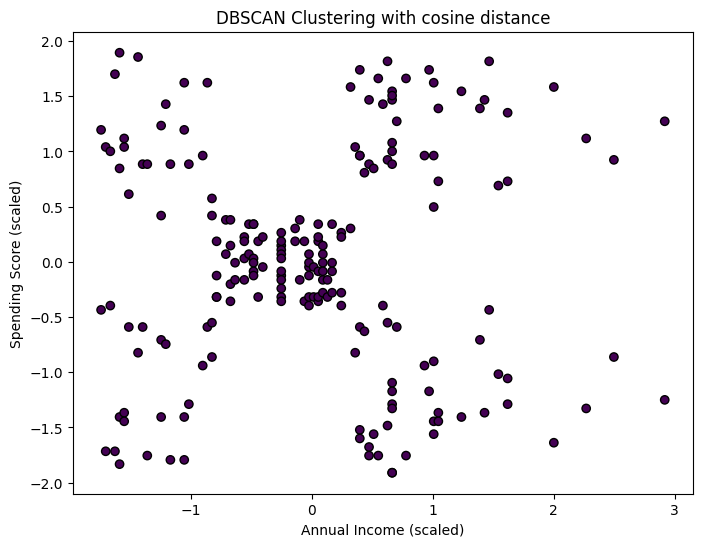

DBSCAN labels for mahalanobis distance:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


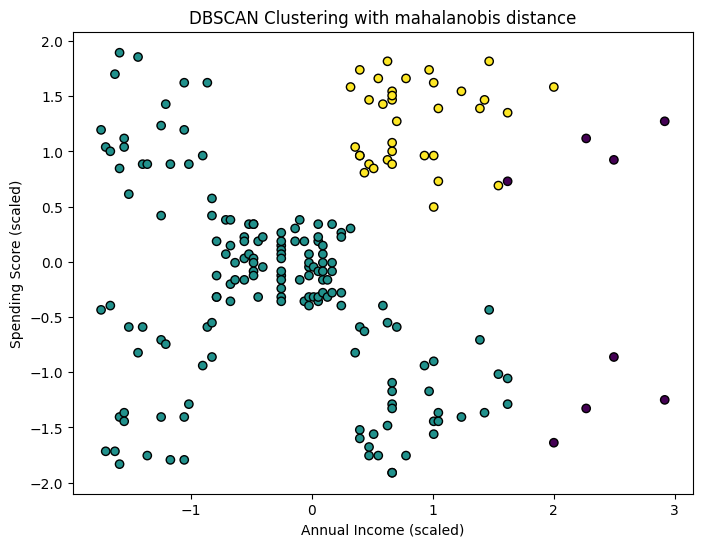

DBSCAN labels for maximum_norm distance:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
  0  0 -1 -1 -1 -1 -1 -1]


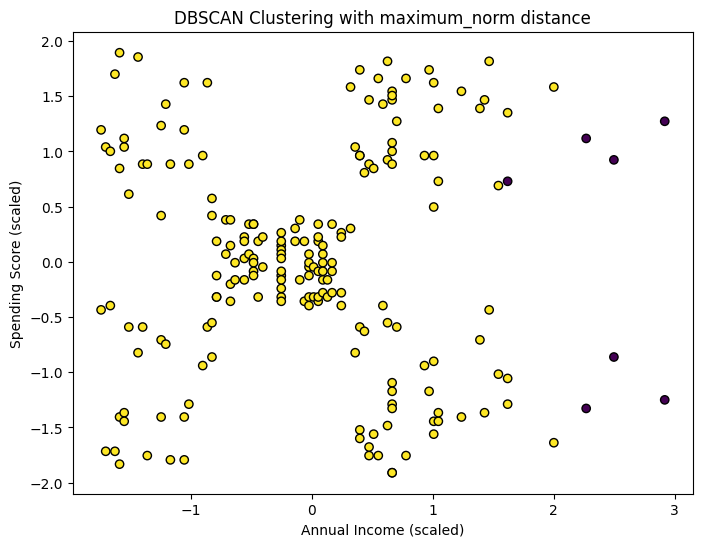

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform



# Selecting important features for clustering (Annual Income and Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply DBSCAN with different distance metrics

# Function to run DBSCAN with different distance metrics
def apply_dbscan(metric):

    if metric == 'mahalanobis':
        # Mahalanobis distance requires the inverse covariance matrix
        cov_matrix = np.cov(X_scaled, rowvar=False)
        inv_cov_matrix = np.linalg.inv(cov_matrix)
        distance_matrix = squareform(pdist(X_scaled, metric='mahalanobis', VI=inv_cov_matrix))
        dbscan = DBSCAN(eps=0.5, min_samples=5, metric='precomputed')
        dbscan_labels = dbscan.fit_predict(distance_matrix)

    elif metric == 'maximum_norm':
        # Chebyshev distance (aka maximum norm) as a precomputed distance matrix
        distance_matrix = squareform(pdist(X_scaled, metric='chebyshev'))
        dbscan = DBSCAN(eps=0.5, min_samples=5, metric='precomputed')
        dbscan_labels = dbscan.fit_predict(distance_matrix)

    else:
        # Other metrics use directly in scikit-learn
        dbscan = DBSCAN(eps=0.5, min_samples=5, metric=metric)
        dbscan_labels = dbscan.fit_predict(X_scaled)

    # Print the labels
    print(f"DBSCAN labels for {metric} distance:")
    print(dbscan_labels)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='viridis', marker='o', edgecolor='k')
    plt.title(f'DBSCAN Clustering with {metric} distance')
    plt.xlabel('Annual Income (scaled)')
    plt.ylabel('Spending Score (scaled)')
    plt.show()

# Step 3: Run DBSCAN with various distance metrics
metrics = ['euclidean', 'manhattan', 'cosine', 'mahalanobis', 'maximum_norm']
for metric in metrics:
    apply_dbscan(metric)


DBSCAN labels for euclidean distance:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


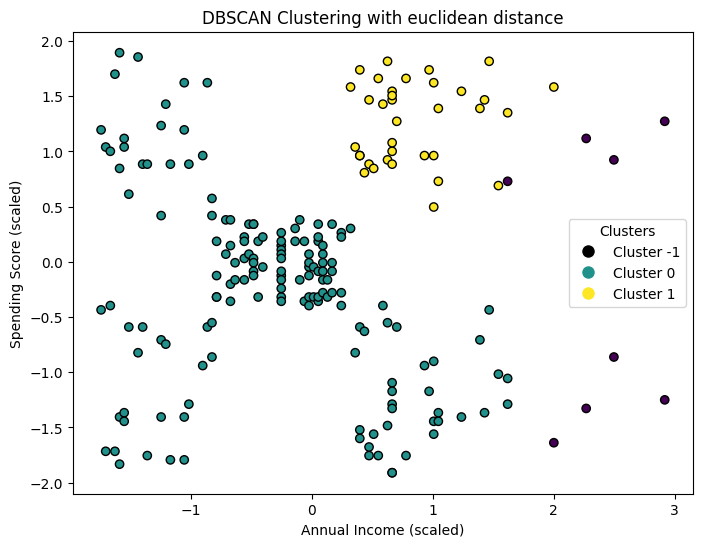

DBSCAN labels for manhattan distance:
[ 0  0  1  0  0  0  1 -1  1  0  1 -1  1  0  1  0  0  0  0 -1  0  0  1  0
  1  0  0  0  0  0  1  0  1  0  1  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  2  0  2  0  2  3  2  3  2  0  2  3  2  3  2  3  2  3  2  0  2
  3  2  0  2  3  2  3  2  3  2  3  2  3  2  3  2  0  2  3  2  3  2  3  2
  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3  2 -1  2  3 -1  3  2  3 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


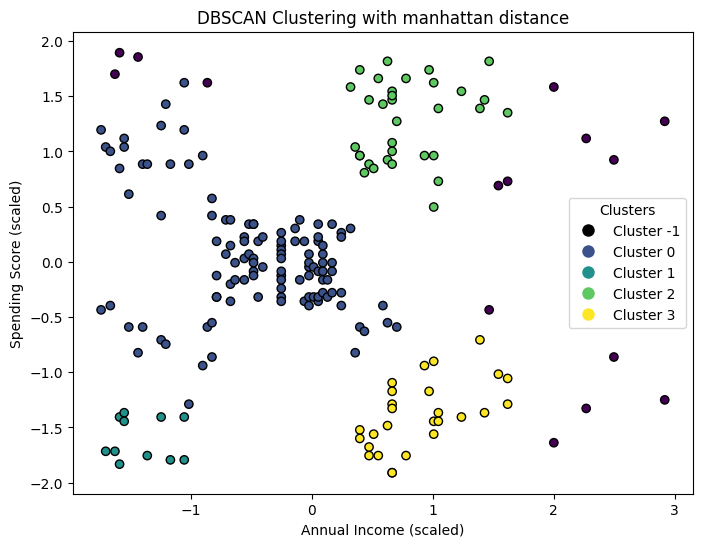

DBSCAN labels for cosine distance:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


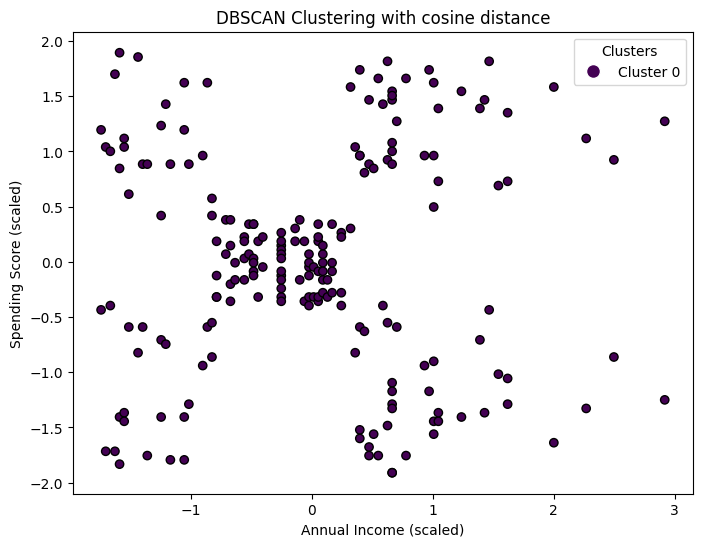

DBSCAN labels for mahalanobis distance:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


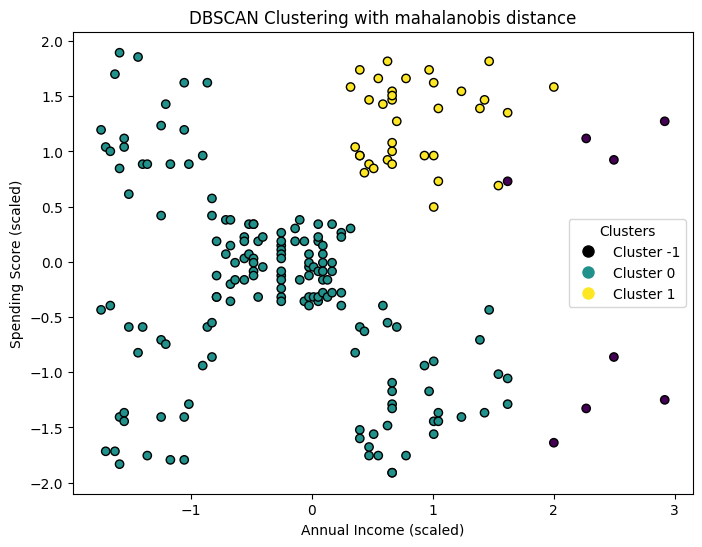

DBSCAN labels for maximum_norm distance:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
  0  0 -1 -1 -1 -1 -1 -1]


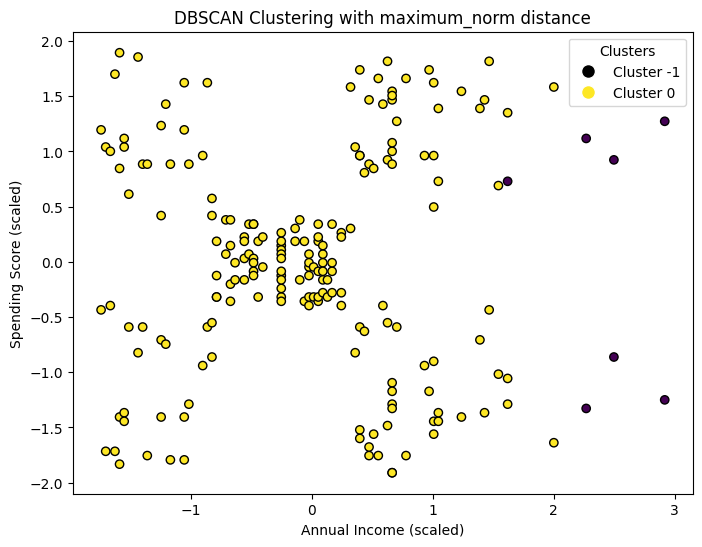

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors

# Assuming df is already loaded with relevant data
# Selecting important features for clustering (Annual Income and Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply DBSCAN with different distance metrics

# Function to run DBSCAN with different distance metrics
def apply_dbscan(metric):
    if metric == 'mahalanobis':
        # Mahalanobis distance requires the inverse covariance matrix
        cov_matrix = np.cov(X_scaled, rowvar=False)
        inv_cov_matrix = np.linalg.inv(cov_matrix)
        distance_matrix = squareform(pdist(X_scaled, metric='mahalanobis', VI=inv_cov_matrix))
        dbscan = DBSCAN(eps=0.5, min_samples=5, metric='precomputed')
        dbscan_labels = dbscan.fit_predict(distance_matrix)

    elif metric == 'maximum_norm':
        # Chebyshev distance (aka maximum norm) as a precomputed distance matrix
        distance_matrix = squareform(pdist(X_scaled, metric='chebyshev'))
        dbscan = DBSCAN(eps=0.5, min_samples=5, metric='precomputed')
        dbscan_labels = dbscan.fit_predict(distance_matrix)

    else:
        # Other metrics use directly in scikit-learn
        dbscan = DBSCAN(eps=0.5, min_samples=5, metric=metric)
        dbscan_labels = dbscan.fit_predict(X_scaled)

    # Print the labels
    print(f"DBSCAN labels for {metric} distance:")
    print(dbscan_labels)

    # Plotting
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='viridis', marker='o', edgecolor='k')
    plt.title(f'DBSCAN Clustering with {metric} distance')
    plt.xlabel('Annual Income (scaled)')
    plt.ylabel('Spending Score (scaled)')

    # Adding a legend
    unique_labels = np.unique(dbscan_labels)
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                          markersize=10, markerfacecolor=mcolors.CSS4_COLORS['black'] if label == -1 else scatter.cmap(scatter.norm(label)))
               for label in unique_labels]
    plt.legend(handles=handles, title="Clusters")

    plt.show()

# Step 3: Run DBSCAN with various distance metrics
metrics = ['euclidean', 'manhattan', 'cosine', 'mahalanobis', 'maximum_norm']
for metric in metrics:
    apply_dbscan(metric)
